<a href="https://colab.research.google.com/github/chitrangada-juneja/CSC480_HWS/blob/homeworks/HW4_480.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

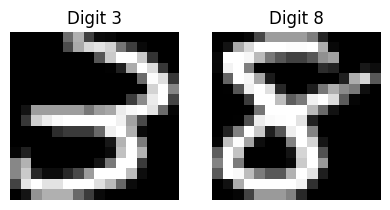

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigs

# File paths
three_path = '/content/drive/MyDrive/data-3/three.txt'
eight_path = '/content/drive/MyDrive/data-3/eight.txt'

# Load the first line of each file
with open(three_path) as f:
    first_three = list(map(int, f.readline().split()))

with open(eight_path) as f:
    first_eight = list(map(int, f.readline().split()))


#now we need the actual array, with each column representing the lines with


img_three = np.array(first_three).reshape(16, 16, order='F')
img_eight = np.array(first_eight).reshape(16, 16, order='F')

# Plot the images
plt.figure(figsize=(10, 5))

plt.subplot(2, 4, 1)
plt.imshow(img_three, cmap='gray')
plt.title('Digit 3')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(img_eight, cmap='gray')
plt.title('Digit 8')
plt.axis('off')

plt.show()



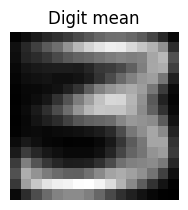

In [38]:
def load_into_arr(file_path):
  #given file_path, for that txt file, we open it
  #process each "line" of 256 digits for one number,
  #do this for the 200 numbers present
  #return an np.arr containing that info

  with open(three_path) as f:
    lines=f.readlines()
  return np.array([list(map(int, line.strip().split())) for line in lines])


X_three = load_into_arr(three_path)
X_eight = load_into_arr(eight_path)


# Combine the data into a 400 x256 array

X = np.vstack([X_three, X_eight])

x_bar = np.mean(X, axis=0)
#print(x_bar)
img_mean = x_bar.reshape(16, 16, order='F')
#elements filled in column by column because given in the question

# Plot the images
plt.figure(figsize=(10, 5))

plt.subplot(2, 4, 1)
plt.imshow(img_mean, cmap='gray')
plt.title('Digit mean')
plt.axis('off')
plt.show()


In [34]:
S =np.cov(X,rowvar=False)
#calcualated covariance

S_sub = S[:5, :5]
print(" 5x5 submatrix of s:\n",S_sub)



 5x5 submatrix of s:
 [[ 1.09030075e+02  2.73623058e+02  5.93511278e+01 -3.64411028e-01
  -8.63132832e+00]
 [ 2.73623058e+02  1.53871439e+03  4.84842206e+02  3.70452130e+01
  -4.91688221e+01]
 [ 5.93511278e+01  4.84842206e+02  1.03508469e+03  3.45675539e+02
  -1.34990226e+01]
 [-3.64411028e-01  3.70452130e+01  3.45675539e+02  6.44105363e+02
   2.71942707e+02]
 [-8.63132832e+00 -4.91688221e+01 -1.34990226e+01  2.71942707e+02
   4.50887193e+02]]


eigen vals:  [243205.67091019+0.j 134881.05522732+0.j]


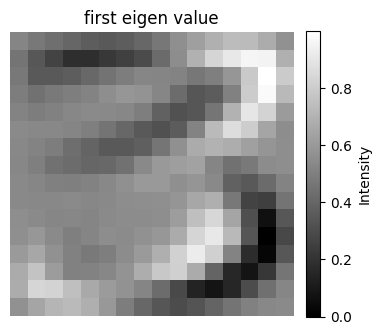

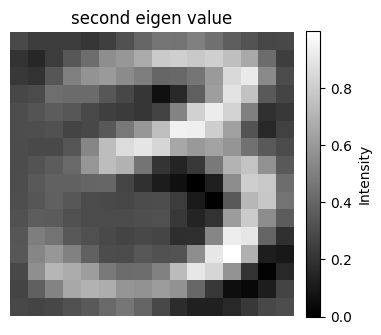

In [52]:
lambda_vals ,lambda_vectors = eigs(S, k=2)

#computed eigen vals and vectors

print("eigen vals: ",lambda_vals)

v_vecs = np.real(lambda_vectors)
sorted_idx = np.argsort(-lambda_vals)
v1, v2 = v_vecs[:, sorted_idx[:2]].T

image = v1.reshape(16, 16, order='F')
# Normalize to [0,1] for grayscale display
min_val = np.min(image)
max_val = np.max(image)
norm_image = (image - min_val) / (max_val - min_val + 1e-8)

    # Show image
plt.figure(figsize=(4, 4))
im = plt.imshow(norm_image, cmap='gray', interpolation='nearest')
plt.title("first eigen value")
plt.axis('off')
plt.colorbar(im, fraction=0.046, pad=0.04, label='Intensity')
plt.show()

image = v2.reshape(16, 16, order='F')
# Normalize to [0,1] for grayscale display
min_val = np.min(image)
max_val = np.max(image)
norm_image = (image - min_val) / (max_val - min_val + 1e-8)

    # Show image
plt.figure(figsize=(4, 4))
im = plt.imshow(norm_image, cmap='gray', interpolation='nearest')
plt.title("second eigen value")
plt.axis('off')
plt.colorbar(im, fraction=0.046, pad=0.04, label='Intensity')
plt.show()

In [53]:
V = np.vstack([v1, v2]).T

X_centered = X - x_bar
X_proj = X_centered @ V  #matrix multiplication of XV

# First projected 3 and 8
print("Projection of first line in three.txt:", X_proj[0])
print("Projection of first line in eight.txt :", X_proj[200])  # 201st row is first eight

Projection of first line in three.txt: [ 417.22328331 -173.65006767]
Projection of first line in eight.txt : [ 417.22328331 -173.65006767]


In [70]:
#we already have XV , we multiplt it to Vtranpose

X_reconstructed = X_proj @ (V.T)  # shape (400, 256)

#the L2 norm is calculated by the linalg.norm , and we find the mean of all of them by np.mean
reconstruction_error = np.mean(np.linalg.norm(X_reconstructed - X_centered, axis=1))

print("Average reconstruction error:", reconstruction_error)



Average reconstruction error: 1069.555235196826


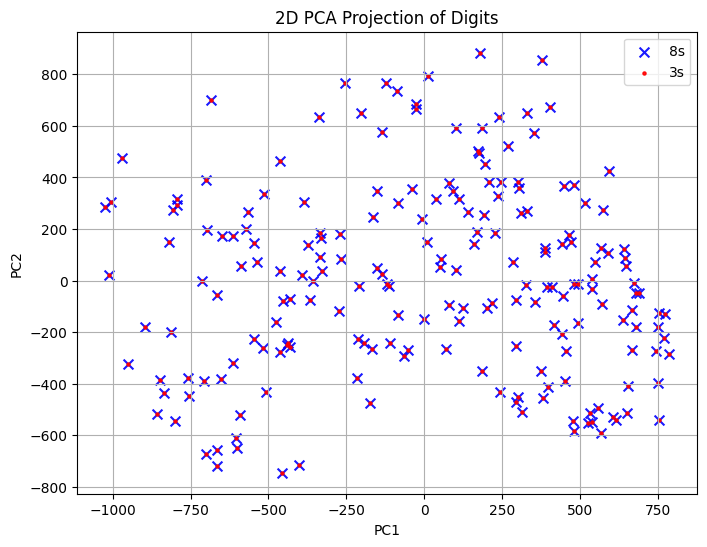

In [78]:
plt.figure(figsize=(8,6))
plt.scatter(X_proj[200:, 0], X_proj[200:, 1], color='blue', label='8s', alpha=0.9, marker='x', s=50)
plt.scatter(X_proj[:200, 0], X_proj[:200, 1], color='red', label='3s', alpha=0.9,marker='o', s=5)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection of Digits")
plt.legend()
plt.grid(True)
plt.show()
